# Melhorando o modelo com Redes Neurais Convolucionais e Data Augmentation

No notebook anterior implementamos um pipeline completo de Deep Learning utilizando uma arquitetura simples para classificar os dígitos da base MNIST.

Embora o modelo tenha apresentado excelente desempenho, ainda existem técnicas capazes de melhorar sua capacidade de generalização, tornando-o mais robusto diante de pequenas variações presentes nas imagens.

Neste notebook manteremos exatamente o mesmo pipeline de treinamento:

```
Carregar dados
      ↓
Definir modelo
      ↓
Compilar modelo
      ↓
Treinar (Fit)
      ↓
Avaliar (Evaluate)
      ↓
Realizar predições
```

A única etapa modificada será a **definição da arquitetura da rede neural**, na qual serão incorporadas técnicas modernas utilizadas em problemas de Visão Computacional.

Entre elas destacam-se:

- Redes Neurais Convolucionais (CNN);
- Data Augmentation;
- MaxPooling;
- Dropout.

Essas técnicas permitem construir modelos mais robustos e com maior capacidade de generalização sem alterar o restante do pipeline de treinamento.

## Carregar dados

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import tensorflow as tf
from tensorflow import keras

mnist = keras.datasets.mnist

I0000 00:00:1782650674.082036    6468 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782650700.347599    6468 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
mnist

<module 'keras.datasets.mnist' from '/home/rusch/anaconda3/lib/python3.13/site-packages/keras/datasets/mnist/__init__.py'>

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
type(x_train[0])

numpy.ndarray

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_train[0][0].shape

(28,)

In [9]:
y_train.shape

(60000,)

In [10]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [11]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [12]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [13]:
contagem = tuple(zip(*np.unique(y_train, return_counts=True)))
contagem

((np.uint8(0), np.int64(5923)),
 (np.uint8(1), np.int64(6742)),
 (np.uint8(2), np.int64(5958)),
 (np.uint8(3), np.int64(6131)),
 (np.uint8(4), np.int64(5842)),
 (np.uint8(5), np.int64(5421)),
 (np.uint8(6), np.int64(5918)),
 (np.uint8(7), np.int64(6265)),
 (np.uint8(8), np.int64(5851)),
 (np.uint8(9), np.int64(5949)))

In [14]:
for par in contagem:
    print(f"{par[0]}: {par[1] / len(y_train) * 100:.2f}%")

0: 9.87%
1: 11.24%
2: 9.93%
3: 10.22%
4: 9.74%
5: 9.04%
6: 9.86%
7: 10.44%
8: 9.75%
9: 9.92%


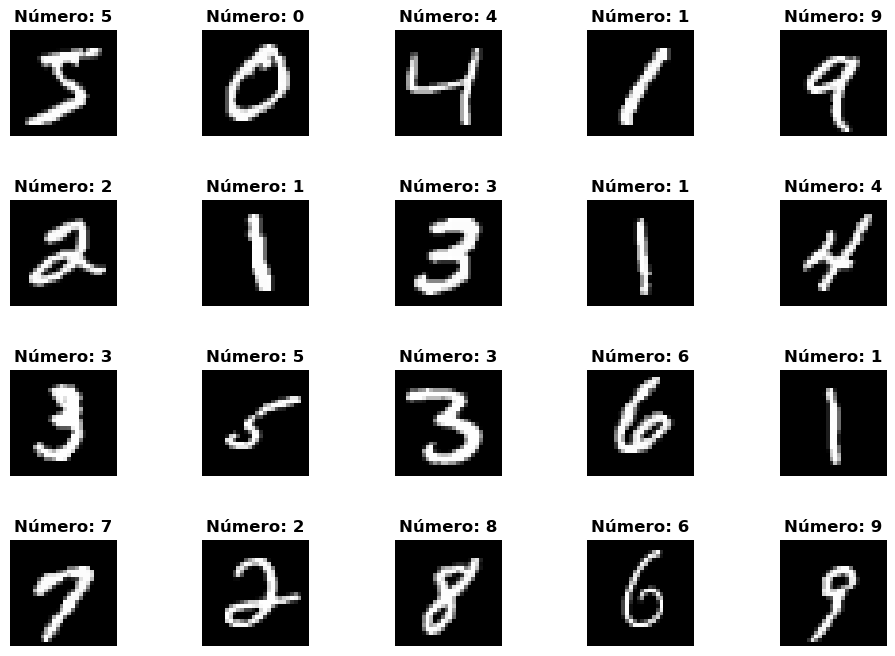

In [44]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Número: {y_train[i]}", fontweight="bold")
    ax.axis("off")

fig.subplots_adjust(hspace=0.6)

plt.show()

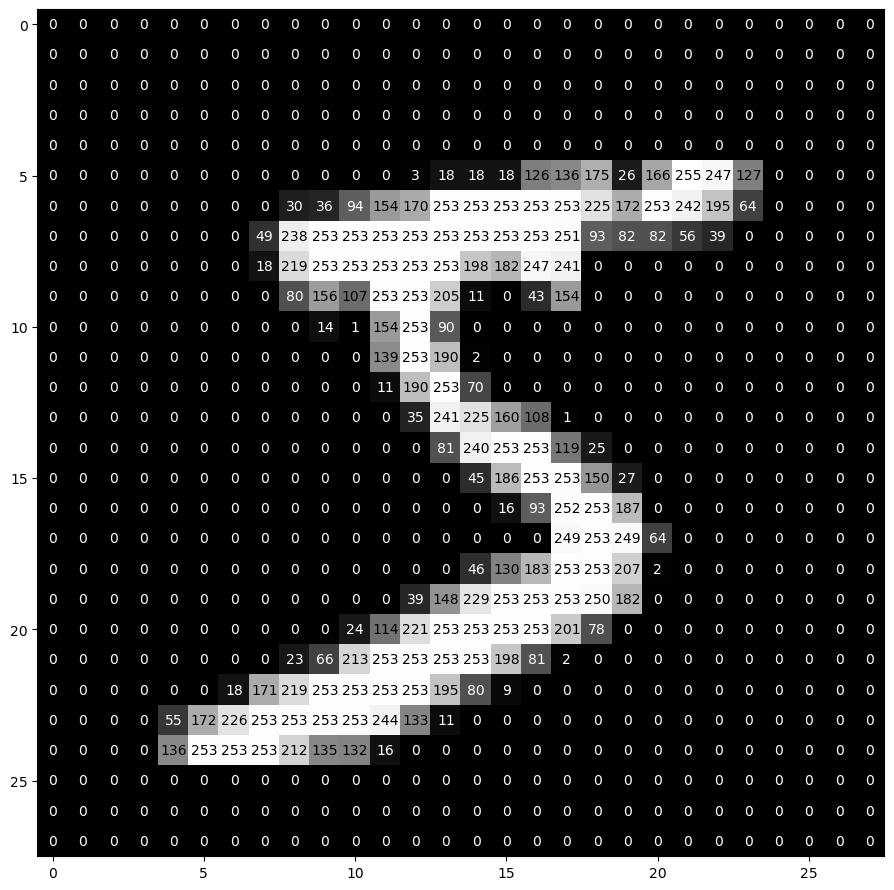

In [16]:
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(x_train[0], cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna]
        ax.annotate(
            str(valor),
            xy=(coluna, linha),
            color="black" if valor > 100 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

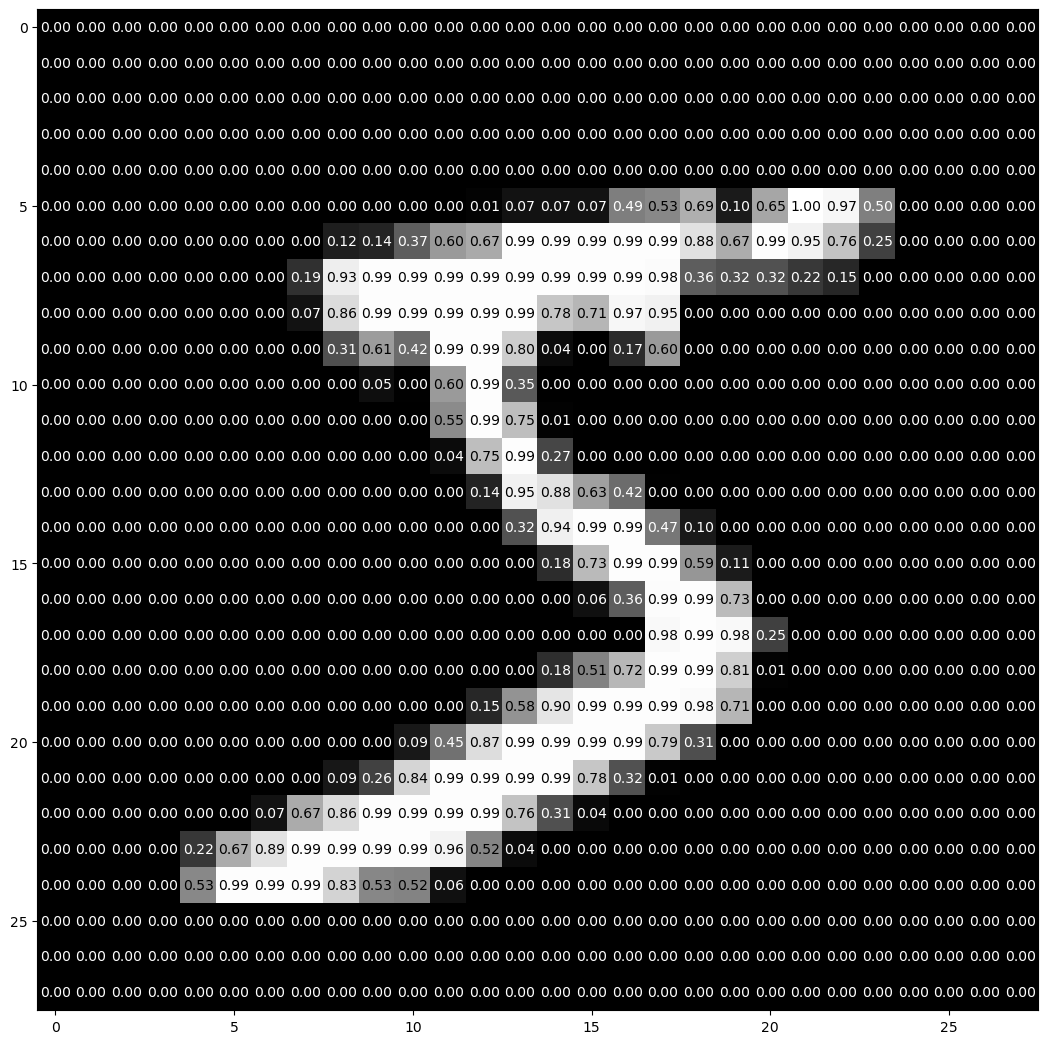

In [17]:
fig, ax = plt.subplots(figsize=(13, 13))

ax.imshow(x_train[0] / 255, cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna] / 255
        ax.annotate(
            f"{valor:.2f}",
            xy=(coluna, linha),
            color="black" if valor > 0.5 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

## Definir modelo Keras

https://www.tensorflow.org/guide/keras/preprocessing_layers

A principal diferença entre este notebook e o anterior está na arquitetura da rede neural.

Enquanto anteriormente utilizamos uma rede densa (*Fully Connected Network*), agora empregaremos uma **Rede Neural Convolucional (CNN)** enriquecida com técnicas de regularização e aumento artificial dos dados.

O objetivo dessas modificações é permitir que a rede aprenda características espaciais das imagens de maneira mais eficiente e reduza o risco de overfitting durante o treinamento.

## Arquitetura proposta

A arquitetura deste modelo combina diferentes camadas, cada uma desempenhando uma função específica no processo de aprendizagem.

| Camada | Finalidade |
|---------|------------|
| RandomRotation | Simula pequenas rotações das imagens durante o treinamento. |
| RandomTranslation | Desloca levemente os dígitos em diferentes direções. |
| RandomZoom | Simula pequenas aproximações e afastamentos da imagem. |
| Convolution | Extrai automaticamente características locais como bordas, curvas e regiões de interesse. |
| MaxPooling2D | Reduz a dimensionalidade preservando as características mais importantes. |
| Dropout | Desativa aleatoriamente neurônios durante o treinamento para reduzir o overfitting. |
| Dense | Realiza a classificação final dos dígitos. |

Embora essas camadas possuam funções distintas, todas trabalham em conjunto para aumentar a capacidade de generalização da rede neural.

In [18]:
model = keras.models.Sequential()

model.add(keras.layers.InputLayer(input_shape=(28, 28, 1)))
model.add(keras.layers.Rescaling(scale=1./255))
model.add(keras.layers.RandomRotation(0.1))
model.add(keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1))
model.add(keras.layers.RandomZoom(0.1))
model.add(keras.layers.Conv2D(64, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Conv2D(128, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()

/home/rusch/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
E0000 00:00:1782650724.310991    6468 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,506 (416.04 KB)

 Trainable params: 106,506 (416.04 KB)

 Non-trainable params: 0 (0.00 B)

### Interpretação da arquitetura

Comparando esta arquitetura com a utilizada no notebook anterior, observa-se um aumento significativo em sua complexidade.

Agora o modelo não apenas aprende a classificar os dígitos, mas também:

- cria automaticamente novas versões das imagens por meio do Data Augmentation;
- extrai características espaciais utilizando convoluções;
- reduz a dimensionalidade através do MaxPooling;
- aplica regularização utilizando Dropout.

Essas modificações tornam a rede mais adequada para problemas de Visão Computacional e representam a base de arquiteturas modernas utilizadas em reconhecimento de imagens.

## Compilar modelo Keras

In [19]:
optimizer = keras.optimizers.Adam(learning_rate=1E-3)
loss = keras.losses.SparseCategoricalCrossentropy()
metric = keras.metrics.SparseCategoricalAccuracy()

model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

## Fit modelo Keras

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    patience=5,
    verbose=1,
    min_delta=1E-4,
)

history = model.fit(
    x_train,
    y_train,
    epochs=300,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
)

Epoch 1/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - loss: 1.2237 - sparse_categorical_accuracy: 0.6022 - val_loss: 0.2236 - val_sparse_categorical_accuracy: 0.9314
Epoch 2/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - loss: 0.5255 - sparse_categorical_accuracy: 0.8388 - val_loss: 0.1413 - val_sparse_categorical_accuracy: 0.9589
Epoch 3/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - loss: 0.4024 - sparse_categorical_accuracy: 0.8750 - val_loss: 0.1068 - val_sparse_categorical_accuracy: 0.9683
Epoch 4/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 0.3307 - sparse_categorical_accuracy: 0.9003 - val_loss: 0.0892 - val_sparse_categorical_accuracy: 0.9740
Epoch 5/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - loss: 0.2872 - sparse_categorical_accuracy: 0.9130 - val_loss: 0.0884 - val_sparse_categorical_accuracy: 0.9725
Epoch 6/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - loss: 0.2603 - sparse_categorical_accuracy: 0.9210 - val_loss: 0.0803 - val_sparse_categorical_accuracy: 0.9762
Epoc

## Evaluate modelo Keras

In [21]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0400 - sparse_categorical_accuracy: 0.9883


[0.040005091577768326, 0.9883000254631042]

A avaliação do modelo sobre o *conjunto de teste* retornou os seguintes valores:

| Métrica | Valor |
|---------|-------:|
| **Loss** | 0,0400 |
| **Accuracy** | 98,83 % |

Esses resultados foram obtidos utilizando imagens que **não participaram do treinamento**, tornando essa etapa a principal medida da capacidade de generalização da rede neural.

A **função de perda (Loss)** igual a aproximadamente **0,04** indica que, em média, o modelo produz previsões muito próximas dos rótulos verdadeiros. Quanto menor o valor da função de perda, menor é o erro cometido durante a classificação.

Já a **acurácia de 98,83%** significa que o modelo classificou corretamente cerca de **9.883 das 10.000 imagens** presentes no conjunto de teste. Em outras palavras, apenas aproximadamente **117 imagens** foram classificadas incorretamente.

Esse desempenho evidencia que a combinação entre **Redes Neurais Convolucionais (CNN)**, **Data Augmentation**, **MaxPooling2D** e **Dropout** produziu um modelo altamente preciso e com excelente capacidade de generalização.

Embora nenhum modelo seja perfeito, uma acurácia próxima de 99% demonstra que a rede conseguiu aprender características relevantes dos dígitos manuscritos sem apresentar perda significativa de desempenho em dados inéditos.

## Predict modelo Keras

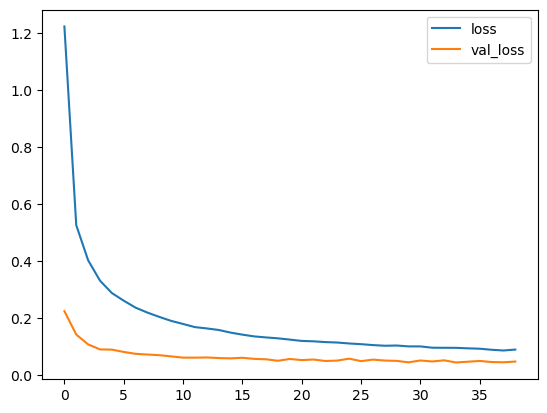

In [22]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

Observa-se que tanto a **Training Loss** (linha azul) quanto a **Validation Loss** (linha laranja) diminuem rapidamente nas primeiras épocas, indicando que a rede neural aprende progressivamente os padrões presentes nas imagens da base MNIST.

Um aspecto interessante deste treinamento é que a perda calculada sobre o conjunto de treinamento permanece superior à perda observada sobre o conjunto de validação. À primeira vista esse comportamento pode parecer inesperado, mas ele é explicado pelas técnicas empregadas na construção do modelo.

Durante o treinamento, as imagens são modificadas continuamente pelas camadas de **Data Augmentation** (RandomRotation, RandomTranslation e RandomZoom), tornando a tarefa de classificação mais desafiadora. Além disso, a camada **Dropout** desativa aleatoriamente parte dos neurônios, dificultando ainda mais o processo de aprendizagem.

Já durante a validação, essas transformações não são aplicadas. O modelo recebe as imagens originais e utiliza toda a sua capacidade computacional, o que naturalmente resulta em uma função de perda menor.

Portanto, esse comportamento não caracteriza overfitting. Pelo contrário, é um forte indicativo de que as técnicas de regularização estão atuando corretamente, tornando o treinamento mais rigoroso e contribuindo para uma melhor capacidade de generalização.

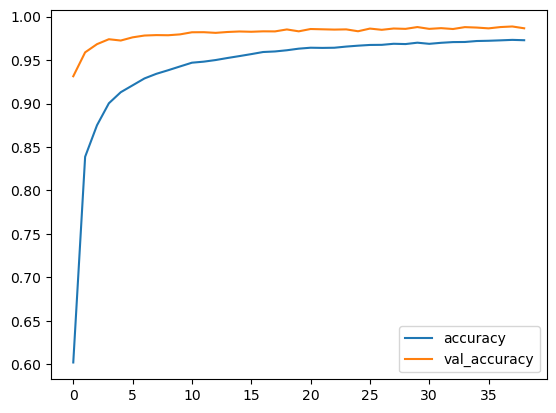

In [23]:
plt.plot(history.history["sparse_categorical_accuracy"], label="accuracy")
plt.plot(history.history["val_sparse_categorical_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

O gráfico da acurácia mostra um crescimento consistente do desempenho da rede neural ao longo do treinamento, indicando que o modelo aprende rapidamente a reconhecer os diferentes dígitos manuscritos da base MNIST.

Observa-se que a **Validation Accuracy** permanece ligeiramente superior à **Training Accuracy** durante praticamente todo o treinamento. Embora esse comportamento pareça contraditório, ele é esperado em modelos que utilizam técnicas de regularização como **Data Augmentation** e **Dropout**.

Durante o treinamento, a rede precisa aprender a partir de imagens artificialmente modificadas e com parte dos neurônios temporariamente desativados. Isso torna a tarefa mais difícil e reduz ligeiramente a acurácia obtida nesse conjunto.

Na etapa de validação, entretanto, o modelo é avaliado utilizando imagens originais e com toda a rede disponível, sem a aplicação das técnicas de regularização. Como consequência, o desempenho tende a ser ligeiramente superior.

Em conjunto com a análise da função de perda e com a elevada acurácia obtida no conjunto de teste (**98,83%**), esses resultados indicam que o modelo apresenta excelente capacidade de generalização e que as técnicas de regularização empregadas contribuíram para reduzir o risco de overfitting.

> **Conclusão**
>
> Comparando este modelo com a arquitetura desenvolvida anteriormente, observa-se que a incorporação de técnicas de **Data Augmentation**, **MaxPooling2D**, **Dropout** e **Early Stopping** contribuiu para a construção de uma rede neural mais robusta. Essas técnicas reduziram o risco de overfitting e permitiram que o modelo mantivesse elevado desempenho tanto nos dados de treinamento quanto em imagens inéditas, evidenciando uma boa capacidade de generalização.

In [24]:
x_test[0].shape

(28, 28)

In [25]:
np.expand_dims(x_test[0], axis=0).shape

(1, 28, 28)

In [36]:
model.predict(np.expand_dims(x_test[0], axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


array([7.7402934e-10, 1.4942320e-07, 2.0581277e-04, 4.8422467e-06,
       5.7548527e-10, 1.1142304e-09, 3.1960280e-17, 9.9978906e-01,
       2.8870481e-08, 1.0267169e-07], dtype=float32)

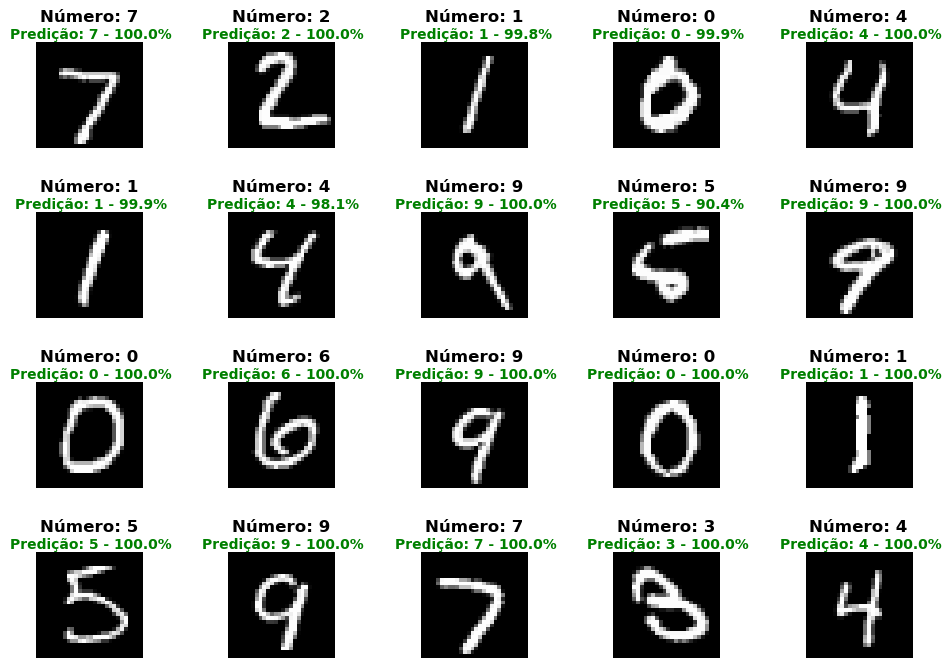

In [38]:
fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"Número: {y_test[i]}", pad=15, fontweight="bold")
    ax.axis("off")
    pred = model.predict(np.expand_dims(x_test[i], axis=0), verbose=0)[0]
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if pred.argmax() == y_test[i] else "red",
        fontweight="bold",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

https://www.tensorflow.org/api_docs/python/tf/keras/utils/load_img

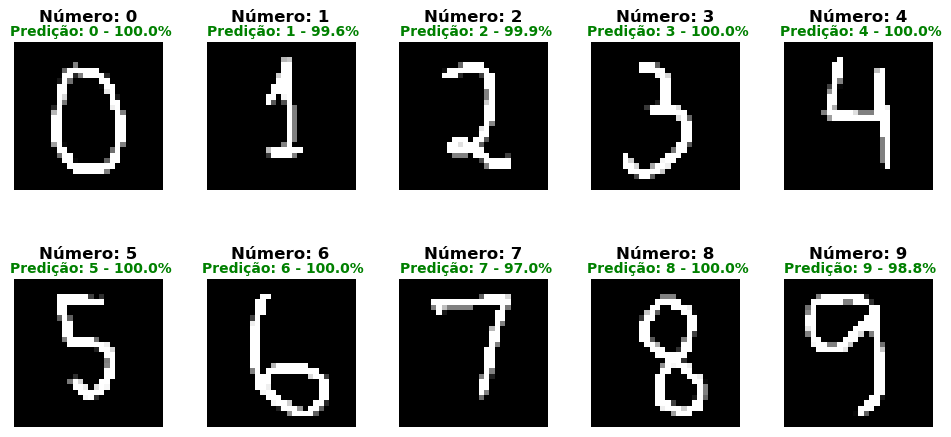

In [43]:
from pathlib import Path

test_images_dir = Path("./data/test_images1")

fig, axs = plt.subplots(2, 5, figsize=(12, 5))

all_pred = {}

for i, (img, ax) in enumerate(zip(sorted(test_images_dir.glob("*.png")), axs.flat)):
    
    name = img.name.split(".")[0]
    
    img = keras.preprocessing.image.load_img(
        img, target_size=(28, 28), color_mode="grayscale"
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = 255 - img_array
    img_array = tf.expand_dims(img_array, 0)
    
    pred = model.predict(img_array, verbose=0)
    all_pred[name] = pred

    ax.imshow(img_array[0], cmap="gray")
    ax.set_title(f"Número: {name}", pad=15, fontweight="bold")
    ax.axis("off")
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if str(pred.argmax()) == name else "red",
        fontweight="bold",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

In [29]:
all_pred["5"]

array([[5.6131614e-12, 3.6096817e-13, 1.5873931e-11, 9.2903527e-08,
        8.0183290e-14, 9.9999964e-01, 7.1203172e-13, 3.2374931e-10,
        3.5228119e-08, 1.6576699e-07]], dtype=float32)

In [30]:
all_pred["6"]

array([[1.3958877e-14, 7.9911137e-16, 5.6100255e-12, 1.0883271e-08,
        8.7094506e-16, 4.9221469e-04, 9.9950767e-01, 7.2340176e-21,
        1.7796656e-07, 7.1225818e-18]], dtype=float32)

In [31]:
all_pred["7"]

array([[1.4842886e-06, 1.6356335e-04, 5.2402834e-03, 2.4572240e-02,
        1.2381346e-10, 5.7086602e-08, 2.2748749e-08, 9.7000557e-01,
        1.6661708e-05, 1.0589392e-07]], dtype=float32)

# Conclusões

Neste notebook mantivemos o pipeline geral de treinamento apresentado anteriormente, porém substituímos a arquitetura da rede neural por uma Rede Neural Convolucional (CNN) enriquecida com técnicas modernas de Data Augmentation e regularização.

As modificações introduzidas permitiram construir um modelo mais robusto, capaz de aprender representações espaciais das imagens e apresentar maior capacidade de generalização.

Nos próximos notebooks avançaremos ainda mais, explorando técnicas de otimização automática de hiperparâmetros, permitindo que o próprio algoritmo descubra configurações capazes de produzir desempenhos superiores.

# Próxima etapa: Otimização automática de hiperparâmetros com Keras Tuner

Nos notebooks anteriores, todas as decisões relacionadas à arquitetura da rede neural foram definidas manualmente. Escolhemos, por exemplo, o número de filtros das camadas convolucionais, a quantidade de neurônios das camadas densas, as taxas de *Dropout* e outros hiperparâmetros com base na experiência e em boas práticas da literatura.

Entretanto, à medida que a complexidade dos modelos aumenta, torna-se inviável testar manualmente todas as combinações possíveis desses hiperparâmetros. Pequenas alterações em seus valores podem produzir diferenças significativas no desempenho final da rede neural.

Para automatizar esse processo, utilizaremos no próximo notebook o **Keras Tuner**, uma biblioteca desenvolvida para realizar a **otimização automática de hiperparâmetros** (*Hyperparameter Optimization*).

Em vez de construir apenas um único modelo, o Keras Tuner gera e avalia diversas arquiteturas diferentes, variando automaticamente parâmetros como:

- número de filtros das camadas convolucionais;
- número de neurônios das camadas densas;
- taxa de *Dropout*;
- taxa de aprendizado (*Learning Rate*);
- entre outros hiperparâmetros definidos pelo usuário.

Cada arquitetura é treinada e avaliada utilizando o conjunto de validação, permitindo identificar aquela que apresenta o melhor desempenho para o problema em estudo.

Dessa forma, o desenvolvimento do modelo deixa de depender exclusivamente da escolha manual do projetista e passa a incorporar um processo sistemático de busca pela melhor configuração da rede neural.

No próximo notebook veremos como configurar o Keras Tuner, definir o espaço de busca dos hiperparâmetros e selecionar automaticamente a arquitetura mais eficiente para a classificação dos dígitos da base MNIST.